In [1]:
import decoupler as dc
import warnings
warnings.filterwarnings("ignore")

import decoupler as dc 
import pandas as pd
import scanpy as sc
import numpy as np
from pyslingshot import Slingshot
import matplotlib.pyplot as plt
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)
import scanpy as sc
import methods as mt
import patchworklib as pw

<Figure size 100x100 with 0 Axes>

In [2]:
adata = sc.read_h5ad("/home/roger/data_itx/adata_all.h5ad")

In [3]:
# Subset data based on interests, as we know that the trajectories differe between conditions, we are going to change that.
cd8_clusters = ["CD8_ex", "CD8_mem", "CD8_eff", "CD8_naive", "CD8_ex_act", "CD8_act"]
adata = adata[adata.obs['celltype'].isin(cd8_clusters)]
adata_post = adata[adata.obs['treatment'] == "post"]
adata_pre = adata[adata.obs['treatment'] == "pre"]

In [4]:
sc.tl.pca(adata_pre, n_comps=16)
sc.pp.neighbors(adata_pre, n_pcs=16)
sc.tl.leiden(adata_pre, resolution=0.7)
sc.tl.umap(adata_pre, min_dist=0.3) 


In [5]:
sc.tl.pca(adata_post, n_comps=16)
sc.pp.neighbors(adata_post, n_pcs=16)
sc.tl.leiden(adata_post, resolution=0.7)
sc.tl.umap(adata_post, min_dist=0.3) 


In [6]:
# we should define a palette for our analysis.
palette_cd4 = {
        "Naive":  "#4C72B0",   # blue
        "Tfh":    "#DD8452",   # orange
        "Th17":   "#55A868",   # green
        "Treg":   "#C44E52",   # red
    }
    
palette_cd8 = {
        "CD8_naive": "skyblue",
        "CD8_mem": "green",
        "CD8_ex": "red",
        "CD8_ex_act": "purple",
        "CD8_eff": "navy",
        "CD8_act": "gold",
    }


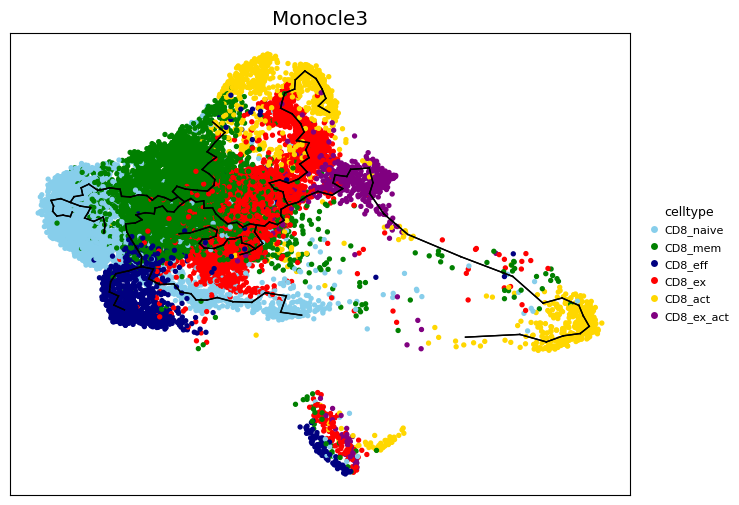

<Axes: title={'center': 'Monocle3'}>

In [7]:
mt.monocle3(adata, palette_cd8)

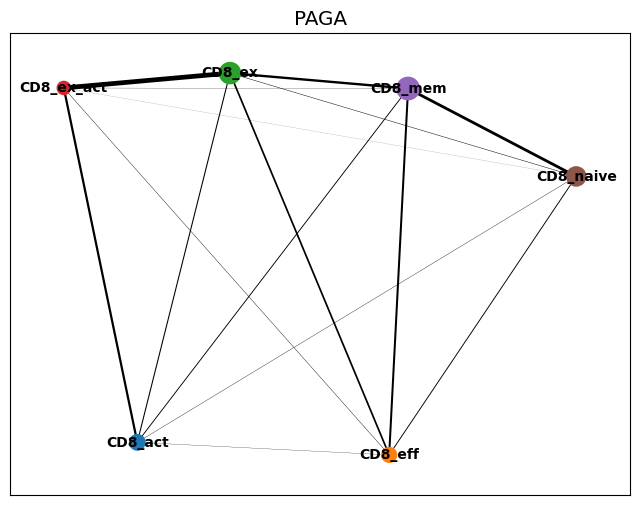

<Axes: title={'center': 'PAGA'}>

In [8]:
mt.run_paga(adata, root_celltype="CD8_naive")

In [9]:
# work with claude to make the different figures and see what i can do... 

Lineages: [Lineage[4, 1, 2, 3, 0], Lineage[4, 5]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @4 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7f6287ed2510>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7f629e173890>]
Shrinking branch @4 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7f6287ed2510>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7f629e173890>]


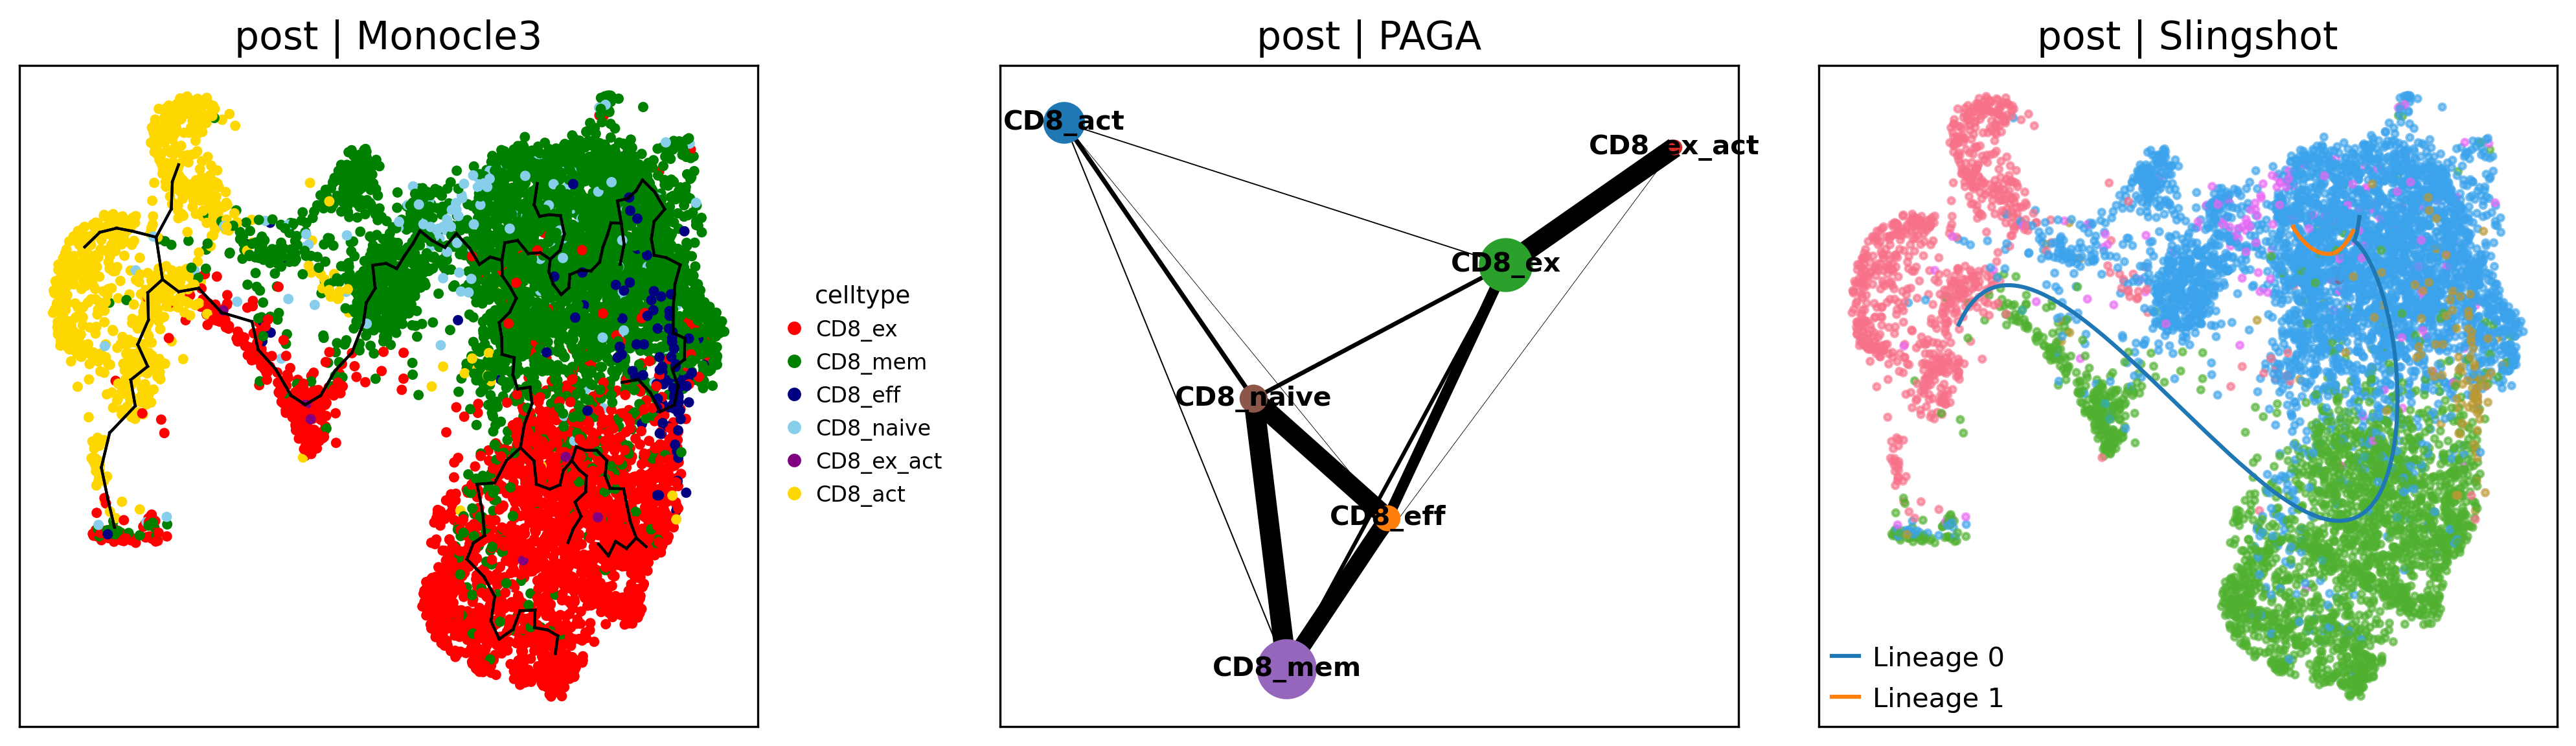

<Figure size 640x480 with 0 Axes>

In [11]:
import methods as mt

mt.plot_trajectory_methods_by_condition(
    adata_post,
    condition_key="treatment",
    conditions=["post"],   # or omit to use all conditions present
    palette_cd8=palette_cd8,
    root_celltype="CD8_naive",
    start_node=4,
)


Lineages: [Lineage[4, 1], Lineage[4, 2, 0, 3], Lineage[4, 5]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @4 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7f6284709810>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7f628470a520>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7f62cf6844d0>]
Shrinking branch @4 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7f6284709810>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7f628470a520>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7f62cf6844d0>]


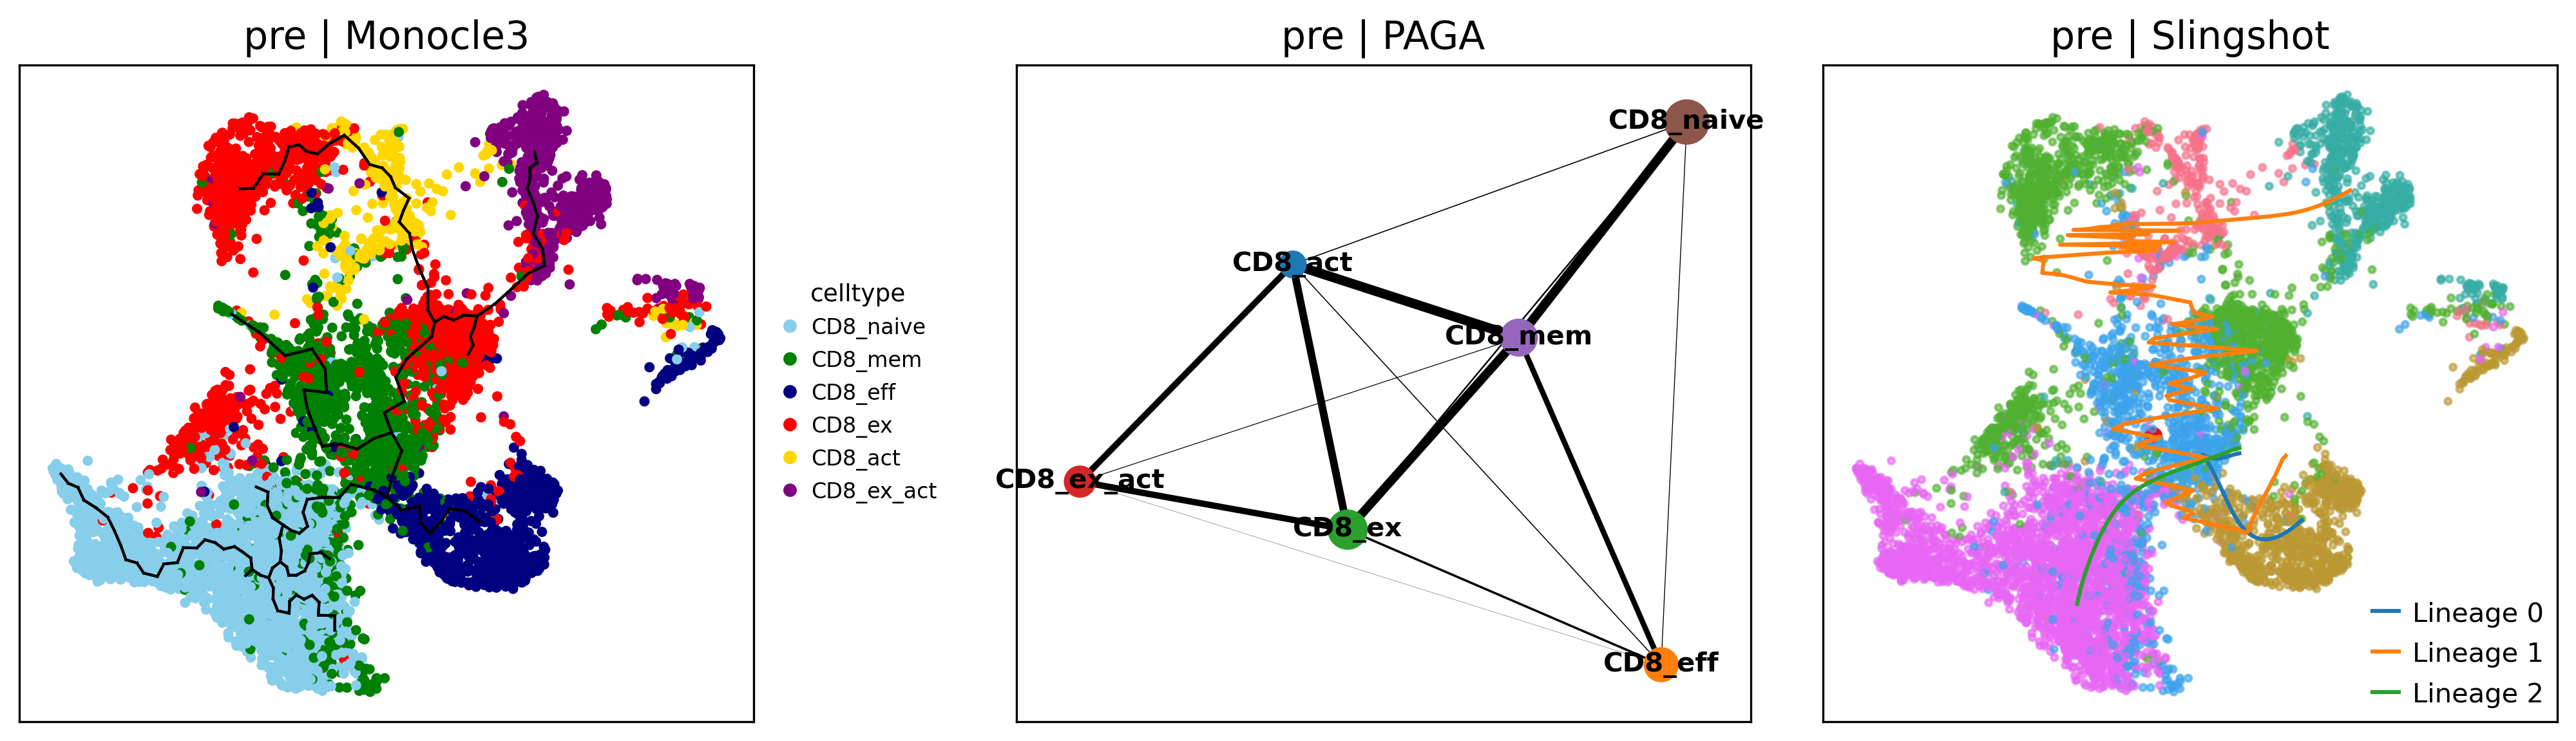

<Figure size 640x480 with 0 Axes>

In [12]:
import methods as mt

mt.plot_trajectory_methods_by_condition(
    adata_pre,
    condition_key="treatment",
    conditions=["pre"],   # or omit to use all conditions present
    palette_cd8=palette_cd8,
    root_celltype="CD8_naive",
    start_node=4,
)
